In [ ]:
!pip install opencv-python-headless -q
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
before_image_path = "before.png"
before_img = cv2.imread(before_image_path)
before_img = cv2.cvtColor(before_img, cv2.COLOR_BGR2RGB)

after_img = cv2.imread("after.png")
after_img = cv2.cvtColor(after_img, cv2.COLOR_BGR2RGB)

In [ ]:
def find_vegetation(img):
    img = img.astype(float)
    red = img[:, :, 0]
    green = img[:, :, 1]
    blue = img[:, :, 2]

    formula = (green-red)/(green+red-blue + 0.0001)
    ans = formula > 0.05

    percent = (np.sum(ans) / ans.size) * 100
    return ans , percent

In [ ]:
full_veg , full_per  = find_vegetation(before_img)
cut_veg , cut_per = find_vegetation(after_img)

In [ ]:
drop = full_per - cut_per

In [ ]:
print("Before vegetation:", full_per )
print("After vegetation:", cut_per)
print("Drop:", drop)

Before vegetation: 39.01192411924119
After vegetation: 23.748577273286575
Drop: 15.263346845954619


(np.float64(-0.5), np.float64(1511.5), np.float64(687.5), np.float64(-0.5))

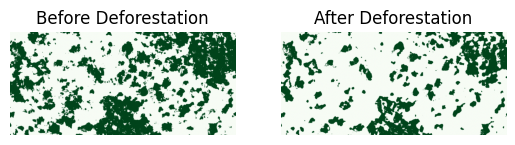

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(full_veg, cmap="Greens")
plt.title("Before Deforestation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cut_veg, cmap="Greens")
plt.title("After Deforestation")
plt.axis("off")


In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
def count_trees(img_tree):
    coords = np.column_stack(np.where(img_tree))

    db = DBSCAN(eps=3, min_samples=5).fit(coords)
    labels = db.labels_
    num_trees = len(set(labels))- (1 if -1 in labels else 0)

    return coords, labels, num_trees

In [ ]:
before_deforestation_coords, before_labels, before_deforestation_count = count_trees(full_veg)
after_deforestation_coords, after_labels, after_deforestation_count = count_trees(cut_veg)

print("Trees before:", before_deforestation_count)
print("Trees after:", after_deforestation_count )

Trees before: 287
Trees after: 151


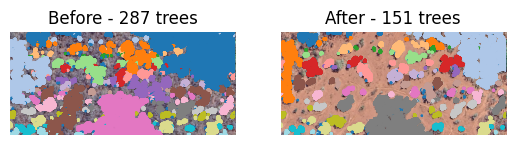

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(before_img)
plt.scatter(before_deforestation_coords[:, 1], before_deforestation_coords[:, 0], c=before_labels, cmap='tab20', s=1)
plt.title(f"Before - {before_deforestation_count} trees")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(after_img)
plt.scatter(after_deforestation_coords[:, 1], after_deforestation_coords[:, 0], c=after_labels, cmap='tab20', s=1)
plt.title(f"After - {after_deforestation_count} trees")
plt.axis("off")

plt.show()